# Inference Evaluator — Local Models

Evaluate **zero-shot** clinical outcome prediction on your test CSV using:
- Raw : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)
- Fine-tuned : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)
- Knowledge Distilled : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)

Metrics reported: **accuracy**, **macro-F1**, **latency** (mean & p95), and **resource usage** (CPU/RAM client-side).

## 1) Configuration
Set your paths and options here. You can point `TEST_CSV` to any CSV that matches the expected schema.

In [36]:
!pip install transformers scikit-learn psutil requests tqdm
!pip install pandas requests


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os

TEST_CSV = os.getenv("INFER_EVAL_TEST_CSV", "dataset/splits/test_synthetic_notes.csv")

# Models
GEMMA3_MODEL_ID = "google/gemma-3-270m-it"

# Inference parameters (deterministic)
GEN_KW = dict(max_new_tokens=2, do_sample=False)

# Optional: limit eval size for quick sanity checks
SAMPLE_LIMIT = None  # e.g., 100 or None for full test set

# Resource sampling interval (seconds)
STATS_INTERVAL = 0.25

print("Config loaded. TEST_CSV=", TEST_CSV)

Config loaded. TEST_CSV= dataset/splits/test_synthetic_notes_sample.csv


## 2) Imports

In [41]:
import time, json, threading
import psutil
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

## 3) Data Loading & Prompt Builder
Build a compact clinical vignette per row and a normalizer to map free-form outputs into the fixed label set.

In [39]:
from textwrap import dedent

df = pd.read_csv(TEST_CSV)
if SAMPLE_LIMIT is not None:
    df = df.sample(SAMPLE_LIMIT, random_state=0).reset_index(drop=True)

def row_to_prompt(note):
    extraction_keys = [     "patient_sex",
                            "patient_age",
                            "diagnosis",
                            "treatment",
                            "clinical_outcome"
                        ]
    keys_fmt = ", ".join([f'"{k}"' for k in extraction_keys])
    prompt = dedent(f'''
    You are an information extraction system for clinical notes.
    Extract the following fields from the note and return a STRICT JSON object with keys: [{keys_fmt}].
    - "patient_sex": string (e.g., "Male" or "Female"; if unknown, "Unknown")
    - "patient_age": integer (years; if unknown, null)
    - "diagnosis": short string summary (primary diagnosis if multiple)
    - "treatment": short string summary of active treatment/medication if present, else "None" or "Unknown"
    - "clinical_outcome": short string (e.g., "stable", "improved", "worsened", "discharged", etc.) if present; else "Unknown"
    - "location": short string (city/state/region if present; else "Unknown")

    Constraints:
    1) Output MUST be valid JSON; do not include code fences or extra commentary.
    2) Keep values concise; avoid long sentences.
    3) If a value is not present, set to "Unknown" (or null for patient_age).

    Note:
    {note}
    ''').strip()
    return prompt

prompts = [row_to_prompt(note) for note in df["synthetic_note"]]

CANONICAL_FIELDS = [
    "patient_sex",
    "patient_age",
    "diagnosis",
    "treatment",
    "clinical_outcome"
]

def auto_map_columns(columns):
    column_patterns = {
        "patient_sex": r"\b(sex|gender|patient_?sex)\b",
        "patient_age": r"\b(age|patient_?age|years?)\b",
        "diagnosis": r"\b(dx|diagnos(e|is|es)|condition|primary_?diagnosis)\b",
        "treatment": r"\b(treatment|therapy|medication|meds|intervention|procedure|rx)\b",
        "clinical_outcome": r"\b(outcome|clinical_?outcome|disposition|status)\b"
    }
    mapping = {k: None for k in CANONICAL_FIELDS}
    for canon, pat in column_patterns.items():
        for c in columns:
            if re.search(pat, c, flags=re.I):
                mapping[canon] = c
                break
    return mapping

column_mapping = auto_map_columns(list(df.columns))

gold = {}

for field in CANONICAL_FIELDS:
    col = column_mapping.get(field)
    if col and col in df.columns:
        gold[field] = df[col].tolist()
    else:
        gold[field] = [None] * len(df)

len(prompts), prompts[0][:200] + "..."

for k, v in gold.items():
    print(f"{k}: {v[:5]}")

KeyError: 'synthetic_note'

## 4) Resource Sampler (CPU/RAM)
Client-side CPU and RAM sampling while inference runs. GPU metrics are omitted for portability.

In [ ]:
class ResourceSampler:
    def __init__(self, interval=0.25):
        self.interval = interval
        self._stop = threading.Event()
        self.samples = []

    def _sample_once(self):
        cpu = psutil.cpu_percent(interval=None)
        mem = psutil.virtual_memory().percent
        self.samples.append({"cpu_percent": cpu, "mem_percent": mem})

    def _run(self):
        while not self._stop.is_set():
            self._sample_once()
            time.sleep(self.interval)

    def start(self):
        self._stop.clear()
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self._stop.set()
        self.thread.join()

    def summary(self):
        if not self.samples:
            return {}
        def max_of(key):
            return max(s.get(key, 0) for s in self.samples)
        def avg_of(key):
            vals = [s.get(key, 0) for s in self.samples]
            return sum(vals)/len(vals) if vals else 0.0
        return {
            "cpu_percent_max": round(max_of("cpu_percent"), 1),
            "cpu_percent_avg": round(avg_of("cpu_percent"), 1),
            "mem_percent_max": round(max_of("mem_percent"), 1),
            "mem_percent_avg": round(avg_of("mem_percent"), 1),
        }


In [ ]:
import re, json, numpy as np

def robust_json_parse(s: str, keys):
    # 1) try direct parse
    try:
        obj = json.loads(s)
    except Exception:
        # 2) fallback: first {...} block
        m = re.search(r'\{.*\}', s, flags=re.S)
        if not m:
            obj = {}
        else:
            try:
                obj = json.loads(m.group(0))
            except Exception:
                obj = {}
    # 3) ensure all expected keys exist with safe defaults
    out = {}
    for k in keys:
        v = obj.get(k, None if k == "patient_age" else "Unknown")
        if k == "patient_age":
            try:
                v = int(float(v)) if v is not None else None
                if v < 0 or v > 120:
                    v = None
            except Exception:
                v = None
        out[k] = v
    return out

## 5) Inference Module for Gemma-3-270M (MPS/CUDA/CPU)
Automatically uses **MPS** on Apple Silicon, **CUDA** if available, otherwise **CPU**.

In [ ]:
import requests

def inference_gemma3(model_id):
    return eval_local(model_id)


def eval_local(model_id):
    
    def generate_chat(p: str):
        messages = [
            {"role": "system", "content": "You are a medical electronic records expert. your objective is to simplify and extract key fields from a bunch of free text with supreme accuracy , someone's life depends on it."},
            {"role": "user", "content": p}
        ]
        payload = {
            "model": model_id,
            "messages": messages,
            "temperature": 0.0,       # mirrors do_sample=False
            "max_tokens": 128,        # mirrors max_new_tokens=128
            "stream": False,
        }
        r = requests.post("http://localhost:8000/v1/chat/completions", json=payload, timeout=120)
        r.raise_for_status()
        data = r.json()
        return data["choices"][0]["message"]["content"].strip()


    sampler = ResourceSampler(interval=STATS_INTERVAL)
    sampler.start()

    latencies = []
    preds = {k: [] for k in CANONICAL_FIELDS}

    t0 = time.time()
    for p in tqdm(prompts, desc=f"Local eval: {model_id}"):
        s = time.time()
        gen_text = generate_chat(p)
        latencies.append(time.time() - s)

        parsed = robust_json_parse(gen_text, CANONICAL_FIELDS)
        for k in CANONICAL_FIELDS:
            preds[k].append(parsed[k])

    total = time.time() - t0
    sampler.stop()
    stats = sampler.summary()

    # --- Sanity checks ---
    n = len(next(iter(preds.values()))) if preds else 0
    for k in CANONICAL_FIELDS:
        if len(preds[k]) != n:
            raise ValueError(f"Pred length mismatch for {k}: {len(preds[k])} vs {n}")
        if k not in gold:
            raise ValueError(f"Missing gold for field: {k}")
        if len(gold[k]) != n:
            raise ValueError(f"Pred/gold mismatch for {k}: {n} vs {len(gold[k])}")

    # --- Simple normalization helpers (inline, minimal changes) ---
    def norm_text(x):
        if x is None:
            return None
        s = str(x).strip().lower()
        if s in {"m", "male"}: return "male"
        if s in {"f", "female"}: return "female"
        if s in {"", "none"}: return "unknown"
        return s

    def to_int_or_none(x):
        try:
            v = int(float(x))
            return v if 0 <= v <= 120 else None
        except Exception:
            return None

    # --- Per-field accuracy ---
    per_field_acc = {}
    for k in CANONICAL_FIELDS:
        if k == "patient_age":
            pvals = [to_int_or_none(v) for v in preds[k]]
            gvals = [to_int_or_none(v) for v in gold[k]]
        else:
            pvals = [norm_text(v) for v in preds[k]]
            gvals = [norm_text(v) for v in gold[k]]
        per_field_acc[k] = float(np.mean([pv == gv for pv, gv in zip(pvals, gvals)]))

    # Keep original return shape: map "accuracy" to mean over fields.
    overall_mean_acc = float(np.mean(list(per_field_acc.values())))
    # macro_f1 isn't meaningful for multi-field mixed outputs; keep interface by echoing overall acc
    macro_f1_like = overall_mean_acc

    # Light "report" string to preserve the original key without refactoring downstream
    report_lines = [f"{k}: acc={per_field_acc[k]:.3f}" for k in CANONICAL_FIELDS]
    report = " | ".join(report_lines)

    print(f"✅ Completed local inference for {model_id}")

    return {
        "model_id": model_id,
        "accuracy": overall_mean_acc,
        "macro_f1": macro_f1_like,
        "per_sample_latency_sec_mean": sum(latencies)/len(latencies) if latencies else 0.0,
        "per_sample_latency_sec_p95": (sorted(latencies)[int(0.95*len(latencies))-1] if latencies else 0.0),
        "total_time_sec": total,
        "resource_stats": stats,
        "report": report,
    }



## 7) Evaluation For Low Compute hungry models
Generates the evaluation report for the given model id in the eval_reports folder. Designed to primarily support on-device models , you can use this same technique for inference if you have high GPU power on device. Otherwise use cloud provider to run inference for bigger models.

In [ ]:
def fmt_pct(x): return f"{100*x:.2f}%"
def fmt_sec(x): return f"{x:.3f}s"

def summarize(r):
    rs = r.get("resource_stats", {})
    return {
        "model": r["model_id"],
        "accuracy": fmt_pct(r["accuracy"]),
        "macro_f1": fmt_pct(r["macro_f1"]),
        "lat_mean": fmt_sec(r["per_sample_latency_sec_mean"]),
        "lat_p95": fmt_sec(r["per_sample_latency_sec_p95"]),
        "total_time": fmt_sec(r["total_time_sec"]),
        "cpu_max%": rs.get("cpu_percent_max"),
        "ram_max%": rs.get("mem_percent_max"),
    }


def run_evaluation_for_low_resource_models(model_id: str):
    results = inference_gemma3(model_id)
    safe_model_id = model_id.replace("/", "_")
    file_path = f"dataset/eval_reports/{safe_model_id}-inference-evaluation.json"
    os.makedirs("dataset/eval_reports", exist_ok=True)
    with open(file_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f'Saved detailed JSON to file "{file_path}"')


## 8) Evaluate Gemma3 - Non fine tuned

In [ ]:
run_evaluation_for_low_resource_models("google/medgemma-4b-it")

Local eval: google/medgemma-4b-it:   1%|          | 18/2000 [00:43<1:20:08,  2.43s/it]


KeyboardInterrupt: 

## Plot Evaluations

In [ ]:
pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import json

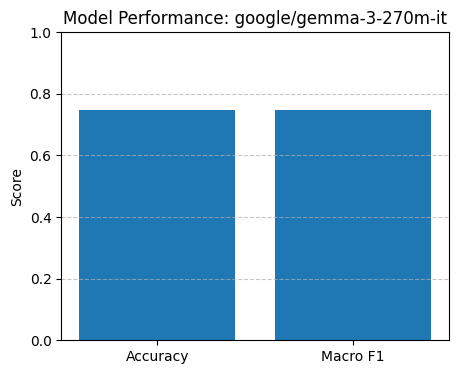

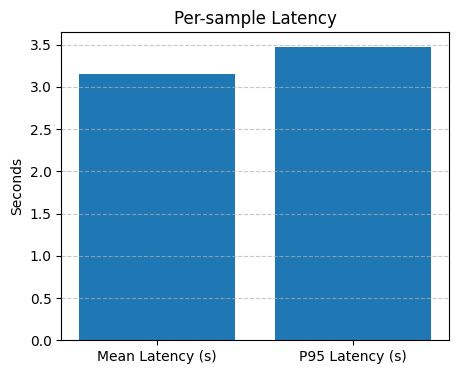

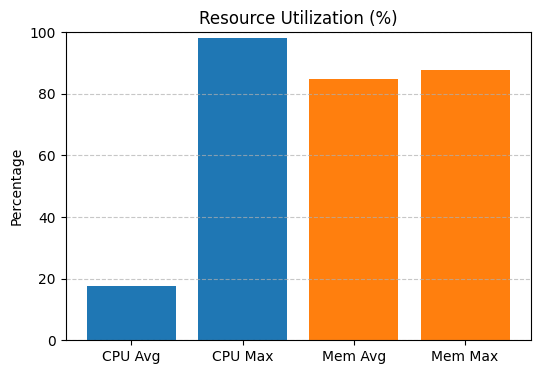

📊 Classification Report:
patient_sex: acc=0.748 | patient_age: acc=0.748 | diagnosis: acc=0.748 | treatment: acc=0.748 | clinical_outcome: acc=0.748


In [ ]:
def plot(model_id: str):
    safe_model_id = model_id.replace("/", "_")
    file_path = f"dataset/eval_reports/{safe_model_id}-inference-evaluation.json"
    # --- Load JSON ---
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, "r") as f:
        data = json.load(f)


    # --- Plot 1: Accuracy and F1 ---
    plt.figure(figsize=(5, 4))
    plt.bar(['Accuracy', 'Macro F1'], [data["accuracy"], data["macro_f1"]])
    plt.title(f'Model Performance: {data["model_id"]}')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plot 2: Latency stats ---
    plt.figure(figsize=(5, 4))
    plt.bar(['Mean Latency (s)', 'P95 Latency (s)'],
            [data["per_sample_latency_sec_mean"], data["per_sample_latency_sec_p95"]])
    plt.title('Per-sample Latency')
    plt.ylabel('Seconds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plot 3: Resource usage ---
    resource = data["resource_stats"]
    labels = ['CPU Avg', 'CPU Max', 'Mem Avg', 'Mem Max']
    values = [resource["cpu_percent_avg"], resource["cpu_percent_max"],
              resource["mem_percent_avg"], resource["mem_percent_max"]]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values, color=['#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e'])
    plt.title('Resource Utilization (%)')
    plt.ylabel('Percentage')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Optional: Print classification report ---
    print("📊 Classification Report:")
    print(data["report"])

plot(GEMMA3_MODEL_ID)